In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile

zip_file_path = '/content/drive/MyDrive/lung cancer.zip'
unzip_dir = '/content/lung_cancer_data'

os.makedirs(unzip_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

print(f'Dataset unzipped to: {unzip_dir}')
print('Contents of unzipped directory:')
print(os.listdir(unzip_dir))

Dataset unzipped to: /content/lung_cancer_data
Contents of unzipped directory:
['Data']


Detected data splits: ['test', 'train', 'valid']
Detected actual classes (from train split): ['normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Number of actual classes: 4


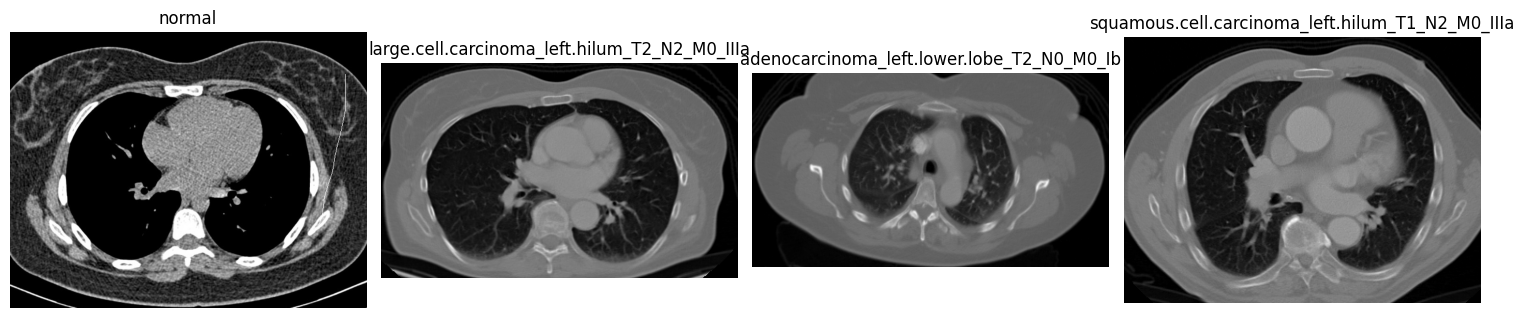

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_dir = os.path.join(unzip_dir, 'Data')

# Get the split directories (e.g., 'train', 'test', 'valid')
split_dirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print(f"Detected data splits: {split_dirs}")

# Assume the actual classes are within one of these splits, e.g., 'train'
# Let's find the actual class names by looking into the 'train' directory
train_dir = os.path.join(data_dir, 'train')
actual_classes = []
if os.path.exists(train_dir):
    actual_classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
    print(f'Detected actual classes (from train split): {actual_classes}')
    print(f'Number of actual classes: {len(actual_classes)}')
else:
    print(f"Train directory not found at: {train_dir}")

# Display a sample image from each actual class
if actual_classes:
    plt.figure(figsize=(15, 5))
    for i, class_name in enumerate(actual_classes):
        # Path to the specific class within the train split
        class_images_path = os.path.join(train_dir, class_name)
        images = [f for f in os.listdir(class_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

        if images:
            sample_image_path = os.path.join(class_images_path, images[0])
            img = mpimg.imread(sample_image_path)

            plt.subplot(1, len(actual_classes), i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')
        else:
            print(f"No images found in class: {class_name} within the train split.")
    plt.tight_layout()
    plt.show()
else:
    print("No actual classes found to display sample images.")

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Path to the dataset
data_dir = os.path.join(unzip_dir, 'Data')
train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'valid')
test_dir = os.path.join(data_dir, 'test')

# Data Augmentation and Rescaling for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for Validation and Test Data (no augmentation)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=actual_classes # Use the actual classes detected earlier
)

validation_generator = validation_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=actual_classes
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=actual_classes
)

print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Class labels: {train_generator.class_indices}")

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(actual_classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
EPOCHS = 10
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 54 images belonging to 4 classes.
Number of training samples: 613
Number of validation samples: 72
Number of test samples: 54
Class labels: {'normal': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,573,828 (13.63 MB)

 Trainable params: 1,315,844 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.4747 - loss: 1.1877 - val_accuracy: 0.3750 - val_loss: 1.0385
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 531ms/step - accuracy: 0.5954 - loss: 0.8936 - val_accuracy: 0.4583 - val_loss: 1.0436
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 565ms/step - accuracy: 0.6183 - loss: 0.8160 - val_accuracy: 0.5417 - val_loss: 0.8774
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 567ms/step - accuracy: 0.7096 - loss: 0.7097 - val_accuracy: 0.5417 - val_loss: 0.8542
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 469ms/step - accuracy: 0.7178 - loss: 0.6915 - val_accuracy: 0.6250 - val_loss: 0.8247
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.7455 - loss: 0.6311 - val_accuracy: 0.6528 - val_loss: 0.7962
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 555ms/step - accuracy: 0.7716 - loss: 0.5967 - val_accuracy: 0.6667 - val_loss: 0.7948
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 498ms/step - accuracy: 0.7700 - loss: 0.5949 - val_accurac

### Continuing Model Training for Additional Epochs

In [11]:
# Define the number of additional epochs
ADDITIONAL_EPOCHS = 5

# Get the current number of epochs already trained
current_epochs = len(history.history['accuracy'])

print(f"Training for {ADDITIONAL_EPOCHS} more epochs, starting from epoch {current_epochs + 1}.")

# Continue training the model
history_extended = model.fit(
    train_generator,
    epochs=current_epochs + ADDITIONAL_EPOCHS, # Total epochs will be current + additional
    initial_epoch=current_epochs, # Start training from where it left off
    validation_data=validation_generator
)

# Combine the history objects for continuous plotting
for key in history.history.keys():
    history.history[key].extend(history_extended.history[key])

# Update the global EPOCHS variable to reflect the new total
EPOCHS = current_epochs + ADDITIONAL_EPOCHS

print(f"Model has now been trained for a total of {EPOCHS} epochs.")

Training for 5 more epochs, starting from epoch 16.
Epoch 16/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 496ms/step - accuracy: 0.8320 - loss: 0.4307 - val_accuracy: 0.7917 - val_loss: 0.6641
Epoch 17/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 545ms/step - accuracy: 0.8695 - loss: 0.4026 - val_accuracy: 0.7083 - val_loss: 0.7313
Epoch 18/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 536ms/step - accuracy: 0.8499 - loss: 0.3941 - val_accuracy: 0.7222 - val_loss: 0.7593
Epoch 19/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 433ms/step - accuracy: 0.8515 - loss: 0.3900 - val_accuracy: 0.7500 - val_loss: 0.6787
Epoch 20/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - accuracy: 0.8532 - loss: 0.3776 - val_accuracy: 0.7500 - val_loss: 0.6405
Model has now been trained for a total of 20 epochs.


### Model Evaluation After Additional Training

In [7]:
# Evaluate the model on the test set after additional training
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss after {ADDITIONAL_EPOCHS} more epochs: {loss:.4f}")
print(f"Test Accuracy after {ADDITIONAL_EPOCHS} more epochs: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.9630 - loss: 0.1585
Test Loss after 5 more epochs: 0.1585
Test Accuracy after 5 more epochs: 0.9630


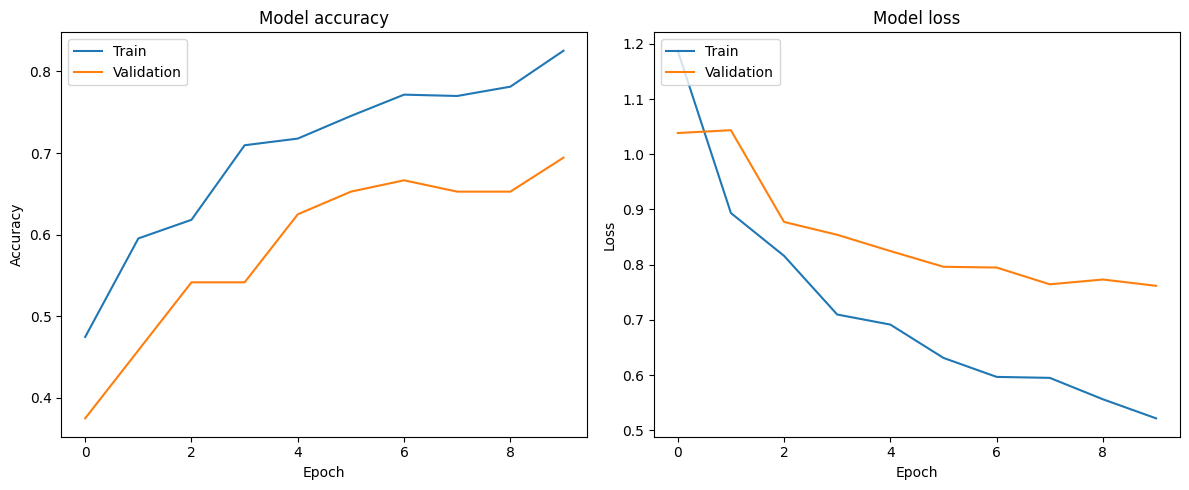

In [5]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

### Predicting on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


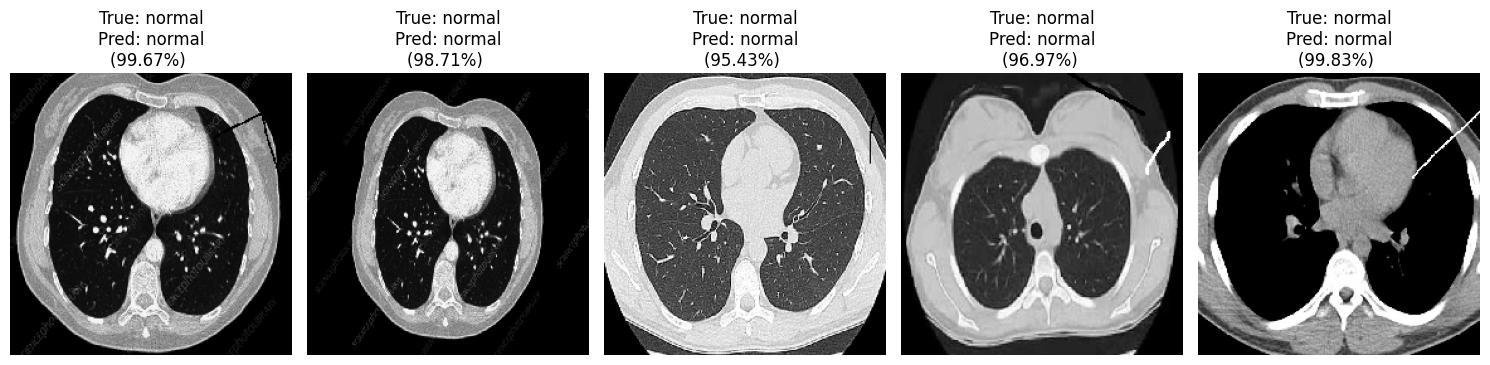

In [8]:
import numpy as np
import random
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get class names from the generator (they are in order of indices)
class_names = list(train_generator.class_indices.keys())

def predict_random_images(model, test_generator, num_samples=5):
    # Get file paths and labels from the test generator
    test_filepaths = test_generator.filepaths
    test_labels = test_generator.classes

    # Select random indices
    random_indices = random.sample(range(len(test_filepaths)), num_samples)

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(random_indices):
        img_path = test_filepaths[idx]
        true_label_idx = test_labels[idx]
        true_label_name = class_names[true_label_idx]

        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Create a batch
        img_array = img_array / 255.0  # Rescale to 0-1

        # Make prediction
        predictions = model.predict(img_array)
        predicted_label_idx = np.argmax(predictions)
        predicted_label_name = class_names[predicted_label_idx]
        confidence = np.max(predictions) * 100

        # Display image and prediction
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}\n({confidence:.2f}%) ")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function to predict on 5 random images from the test set
predict_random_images(model, test_generator, num_samples=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


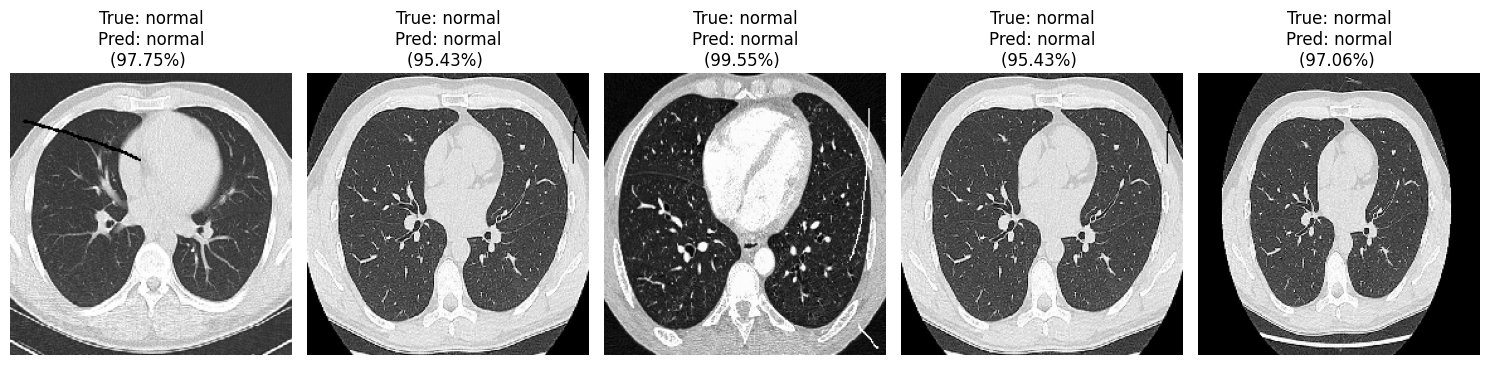

In [9]:
# Call the function again to predict on another 5 random images from the test set
predict_random_images(model, test_generator, num_samples=5)

### Creating a Gradio Interface for Image Classification

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

# Get class names from the generator (they are in order of indices)
class_names = list(train_generator.class_indices.keys())

def classify_image(img):
    # Preprocess the image
    img_resized = image.array_to_img(img, scale=False).resize((IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)  # Create a batch
    img_array = img_array / 255.0  # Rescale to 0-1

    # Make prediction
    predictions = model.predict(img_array)
    predicted_label_idx = np.argmax(predictions)
    confidence = predictions[0][predicted_label_idx]

    # Prepare output for Gradio
    prediction_probabilities = {class_names[i]: float(predictions[0][i]) for i in range(len(class_names))}

    return prediction_probabilities

# Create Gradio interface
iface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy", label="Upload Lung Image"),
    outputs=gr.Label(),
    title="Lung Cancer Image Classifier",
    description="Upload a lung image to classify it into one of four categories: normal, large cell carcinoma, adenocarcinoma, or squamous cell carcinoma."
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7e9d3f6f230d7a1965.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
